In [1]:
!pip install transformers
!pip install torch
!pip install pandas
!pip install numpy
!pip install scikit-learn
!pip install matplotlib
!pip install seaborn

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    BertTokenizer, BertModel, get_linear_schedule_with_warmup
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import resample

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 54.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 60.8 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [2]:
# Load and preprocess data (same as original)
df = pd.read_csv('/content/urdusentiment.csv')


In [3]:
# Step 1: Display total rows and columns in the dataset
print("Total rows and columns in the dataset:")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")


Total rows and columns in the dataset:
Rows: 10008, Columns: 5


In [5]:
# Step 2: Display total count of tweets before removing neutral tweets
print("\nTotal count of tweets before removing neutral tweets:")
print(df['Lables'].value_counts())


Total count of tweets before removing neutral tweets:
Lables
neu    3728
pos    3719
neg    2561
Name: count, dtype: int64


In [6]:
# Check for null values
print("\nChecking for null values:")
print(df.isnull().sum())


Checking for null values:
Urdu Text Data    0
1                 0
2                 2
3                 0
Lables            0
dtype: int64


In [7]:
# Remove null values
df = df.dropna()
print("\nNull values removed.")


Null values removed.


In [8]:
# Check for null values
print("\nChecking for null values:")
print(df.isnull().sum())


Checking for null values:
Urdu Text Data    0
1                 0
2                 0
3                 0
Lables            0
dtype: int64


In [9]:
# Step 3: Filter out neutral tweets and convert to binary classification
df = df[df['Lables'] != 'neu']
df['label'] = df['Lables'].map({'pos': 1, 'neg': 0})

<ipython-input-9-bc34383775bf>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['label'] = df['Lables'].map({'pos': 1, 'neg': 0})


In [10]:
# More thorough text cleaning
def clean_text(text):
    text = str(text)
    # Remove special characters and normalize
    text = text.replace('\\', '').replace('"', '').replace('\n', ' ')
    text = text.strip()
    return text

df['Urdu Text Data'] = df['Urdu Text Data'].apply(clean_text)


In [11]:
# Step 4: Display total count of tweets after removing neutral tweets
print("\nTotal count of tweets after removing neutral tweets:")
print(df['label'].value_counts())


Total count of tweets after removing neutral tweets:
label
1    3718
0    2561
Name: count, dtype: int64


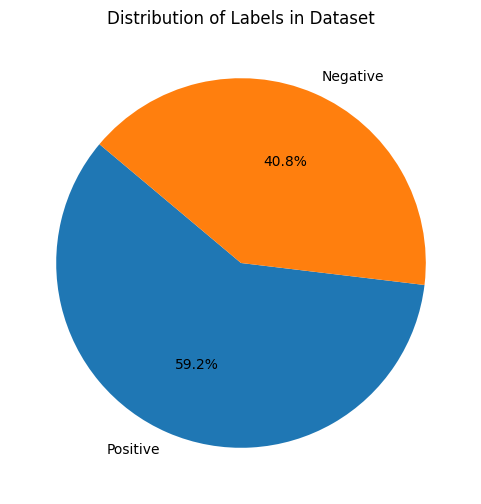

In [12]:
# Pie chart of dataset
label_counts = df['label'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(label_counts, labels=['Positive', 'Negative'], autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Labels in Dataset')
plt.show()

In [ ]:
# Handle class imbalance
#df_majority = df[df['label']==1]
#df_minority = df[df['label']==0]

#df_minority_upsampled = resample(df_minority,
                                # replace=True,
                                 #n_samples=len(df_majority),
                                 #random_state=42)

#df = pd.concat([df_majority, df_minority_upsampled])


In [14]:
# Step 2: Display the total count of tweets after balancing.
#print("\nTotal count of tweets after balancing positive and negative tweets:")
#print(df['Lables'].value_counts())

In [15]:
# Pie chart of dataset
#label_counts = df['label'].value_counts()
#plt.figure(figsize=(6, 6))
#plt.pie(label_counts, labels=['Positive', 'Negative'], autopct='%1.1f%%', startangle=140)
#plt.title('Distribution of Labels in Dataset')
#plt.show()

In [16]:
# Split into train and validation sets
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['Urdu Text Data'], df['label'], test_size=0.2, random_state=42
)

In [17]:
# Initialize BERT tokenizer with longer max length
tokenizer = BertTokenizer.from_pretrained('bert-base-multilingual-cased')

# Custom Dataset class (same as original)
class UrduDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts.iloc[idx])
        label = self.labels.iloc[idx]

        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(label, dtype=torch.long)
        }


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

In [18]:
# Create datasets and dataloaders with larger batch size
train_dataset = UrduDataset(train_texts, train_labels, tokenizer, max_len=256)
val_dataset = UrduDataset(val_texts, val_labels, tokenizer, max_len=256)

BATCH_SIZE = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

In [19]:
# Enhanced Hybrid BERT-BiLSTM Model with Attention
class BERTBiLSTMAttention(nn.Module):
    def __init__(self, bert_model_name, hidden_dim=256, num_layers=2, dropout=0.3):
        super(BERTBiLSTMAttention, self).__init__()
        self.bert = BertModel.from_pretrained(bert_model_name)
        self.lstm = nn.LSTM(
            input_size=self.bert.config.hidden_size,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            bidirectional=True,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)

        # Attention mechanism
        self.attention = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
            nn.Softmax(dim=1)
        )

        self.classifier = nn.Linear(hidden_dim * 2, 2)

    def forward(self, input_ids, attention_mask):
        bert_output = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        sequence_output = bert_output.last_hidden_state

        lstm_output, _ = self.lstm(sequence_output)
        lstm_output = self.dropout(lstm_output)

        # Attention mechanism
        attention_weights = self.attention(lstm_output)
        context_vector = torch.sum(attention_weights * lstm_output, dim=1)

        logits = self.classifier(context_vector)
        return logits

In [20]:
# Initialize model with larger hidden dimension
HIDDEN_DIM = 512
NUM_LAYERS = 2
model = BERTBiLSTMAttention(
    bert_model_name='bert-base-multilingual-cased',
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    dropout=0.3
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)


model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

In [21]:
# Training setup with learning rate scheduling
from torch.optim import AdamW # Import AdamW from torch.optim

EPOCHS = 10
LEARNING_RATE = 2e-5
# Remove the 'correct_bias' argument
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss().to(device)

In [22]:
# Learning rate scheduler
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

In [23]:
# Early stopping
best_accuracy = 0
patience = 3
trigger_times = 0

In [24]:
# Training function with gradient clipping
def train_model(model, data_loader, optimizer, criterion, device, scheduler=None):
    model.train()
    total_loss = 0

    for batch in data_loader:
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs, labels)

        total_loss += loss.item()

        loss.backward()
        # Gradient clipping
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        if scheduler:
            scheduler.step()

    return total_loss / len(data_loader)

In [25]:
# Enhanced evaluation function
def evaluate_model(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0
    predictions = []
    true_labels = []
    probabilities = []

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            _, preds = torch.max(outputs, dim=1)
            probs = torch.softmax(outputs, dim=1)

            predictions.extend(preds.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())
            probabilities.extend(probs.cpu().numpy())

    return {
        'loss': total_loss / len(data_loader),
        'predictions': np.array(predictions),
        'true_labels': np.array(true_labels),
        'probabilities': np.array(probabilities)
    }


In [26]:
# Training loop with early stopping
for epoch in range(EPOCHS):
    train_loss = train_model(model, train_loader, optimizer, criterion, device, scheduler)
    val_results = evaluate_model(model, val_loader, criterion, device)

    # Calculate accuracy
    val_accuracy = accuracy_score(val_results['true_labels'], val_results['predictions'])

    print(f'Epoch {epoch + 1}/{EPOCHS}')
    print(f'Train Loss: {train_loss:.4f}')
    print(f'Val Loss: {val_results["loss"]:.4f}')
    print(f'Val Accuracy: {val_accuracy:.4f}')
    print('-' * 50)
    # Early stopping
    if val_accuracy > best_accuracy:
        best_accuracy = val_accuracy
        trigger_times = 0
        torch.save(model.state_dict(), 'best_model.bin')
    else:
        trigger_times += 1
        if trigger_times >= patience:
            print(f'Early stopping! Best accuracy: {best_accuracy:.4f}')
            break


Epoch 1/10
Train Loss: 0.4737
Val Loss: 0.4071
Val Accuracy: 0.8400
--------------------------------------------------
Epoch 2/10
Train Loss: 0.3096
Val Loss: 0.4921
Val Accuracy: 0.8368
--------------------------------------------------
Epoch 3/10
Train Loss: 0.2294
Val Loss: 0.5169
Val Accuracy: 0.8694
--------------------------------------------------
Epoch 4/10
Train Loss: 0.1641
Val Loss: 0.5082
Val Accuracy: 0.8678
--------------------------------------------------
Epoch 5/10
Train Loss: 0.1287
Val Loss: 0.6708
Val Accuracy: 0.8670
--------------------------------------------------
Epoch 6/10
Train Loss: 0.0951
Val Loss: 0.6453
Val Accuracy: 0.8710
--------------------------------------------------
Epoch 7/10
Train Loss: 0.0612
Val Loss: 0.7274
Val Accuracy: 0.8742
--------------------------------------------------
Epoch 8/10
Train Loss: 0.0353
Val Loss: 0.8008
Val Accuracy: 0.8678
--------------------------------------------------
Epoch 9/10
Train Loss: 0.0243
Val Loss: 0.8355
V

In [35]:
# Training loop with early stopping
for epoch in range(EPOCHS):
    # ... (rest of the training loop code)

    # Early stopping
    if val_accuracy > best_accuracy:
        best_accuracy = val_accuracy
        trigger_times = 0
        # Save the model state dictionary with a full path
        # for example:
        model_save_path = '/content/best_model.bin'  # Specify the desired path
        torch.save(model.state_dict(), model_save_path)
    # ... (rest of the training loop code)

# ... (later in your code when loading the model)

# Load best model using the same path used for saving
model.load_state_dict(torch.load(model_save_path))

<All keys matched successfully>

In [36]:
# Final evaluation with more metrics
val_results = evaluate_model(model, val_loader, criterion, device)


In [37]:
print("\nClassification Report:")
print(classification_report(val_results['true_labels'], val_results['predictions']))



Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.85      0.85       524
           1       0.89      0.90      0.89       732

    accuracy                           0.88      1256
   macro avg       0.87      0.87      0.87      1256
weighted avg       0.87      0.88      0.87      1256



In [39]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

# Assuming val_results contains 'true_labels' and 'predictions'
true_labels = val_results['true_labels']
predictions = val_results['predictions']

# Calculate metrics
accuracy = accuracy_score(true_labels, predictions)
f1 = f1_score(true_labels, predictions)
recall = recall_score(true_labels, predictions)
precision = precision_score(true_labels, predictions)

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Precision: {precision:.4f}")

Accuracy: 0.8750
F1 Score: 0.8931
Recall: 0.8962
Precision: 0.8901


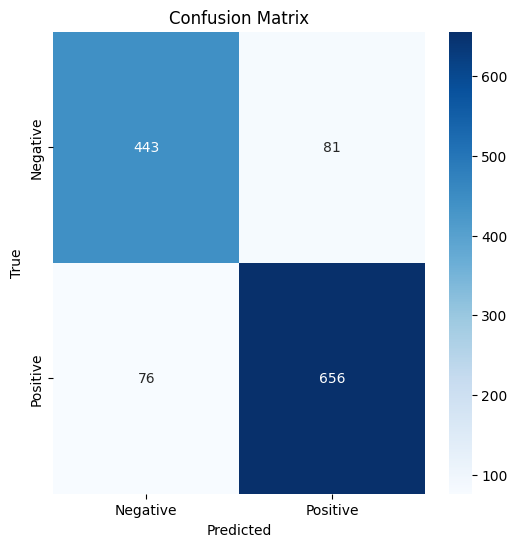

In [40]:
# Plot confusion matrix
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

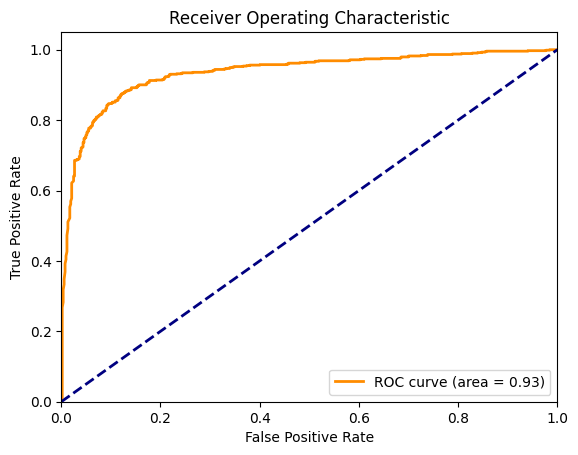

In [41]:
# Plot ROC curve
fpr, tpr, thresholds = roc_curve(val_results['true_labels'], val_results['probabilities'][:, 1])
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()